# 03 — Criteo profiling: marketing uplift structure

Fits `docs/calibration_spec.md` Section 3 and writes `simulation/params/uplift_params.json`.
Foundational facts about the dataset (randomized design, ITT-vs-exposure, balance, rarity)
are established in `03a_criteo_eda.ipynb` and cited rather than re-derived. Follows the
data-mutation ledger convention (Section 0, v0.2).

Provenance: A — agent-built per the calibration spec; assumptions cite decision ids.

**What this fits (spec Section 3):** the treatment/holdout ratio; the control-arm baseline
conversion rate; the ITT uplift effect (absolute and relative); the heterogeneity *spread*
(top-decile-to-average ratio, C6) via a T-learner, ported into engagement-segment multipliers
the simulator applies to its consumers; and the declared message-funnel rates (C5 — Criteo has
no email funnel, so send->open->click are industry-plausible inventions).

**QA gates (spec Section 3):** a simulated holdout experiment, analyzed naively, recovers the
injected uplift within its own 95% CI; the recovered segment spread matches the injected
spread; the treatment split matches the fitted ratio. Qini curve produced as an exhibit —
its modest shape (not a toy staircase) is the realism check.


In [1]:
# Configuration and the mutation ledger (spec Section 0 conventions).
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

SEED = 42
rng = np.random.default_rng(SEED)

ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "pyproject.toml").exists()
PARAMS_PATH = ROOT / "simulation" / "params" / "uplift_params.json"
FEATURES = [f"f{i}" for i in range(12)]

MUTATIONS = []
def record_mutation(step, column, rows, disposition, rationale):
    MUTATIONS.append({"step": step, "column": column, "rows_affected": int(rows),
                      "disposition": disposition, "rationale": rationale})
    print(f"[mutation] {step} / {column}: {rows:,} rows — {disposition}")

d = pd.read_csv(ROOT / "data" / "raw" / "criteo" / "criteo-uplift-v2.1.csv.gz")
print(f"rows: {len(d):,} (no nulls anywhere — see 03a; no cleaning mutations required)")


rows: 13,979,592 (no nulls anywhere — see 03a; no cleaning mutations required)


## 1. Headline fits: ratio, baseline, ITT effect


In [2]:
treatment_ratio = float(d["treatment"].mean())
t, c = d[d.treatment == 1], d[d.treatment == 0]
baseline_conversion = float(c["conversion"].mean())
ate = float(t["conversion"].mean() - baseline_conversion)
se = float(np.sqrt(t.conversion.var()/len(t) + c.conversion.var()/len(c)))
print(f"treatment ratio: {treatment_ratio:.4f}  (C6 declared ~85/15)")
print(f"control-arm baseline conversion: {baseline_conversion:.5f}")
print(f"ITT uplift: {ate*100:+.3f}pp  (95% CI +/- {1.96*se*100:.3f}pp)  "
      f"relative {ate/baseline_conversion:+.1%}")
print(f"C6 declared band +0.1 to +0.3pp: {'inside' if 0.001 <= ate <= 0.003 else 'OUTSIDE'}")


treatment ratio: 0.8500  (C6 declared ~85/15)
control-arm baseline conversion: 0.00194
ITT uplift: +0.115pp  (95% CI +/- 0.007pp)  relative +59.4%
C6 declared band +0.1 to +0.3pp: inside


## 2. Heterogeneity: T-learner and the segment multipliers

A T-learner (separate outcome models per arm, uplift score = difference of predictions) is
fitted on 60% of the data; heterogeneity is then *evaluated* on the held-out 40% by ranking
users on the fitted score and computing the **actual** treated-minus-control conversion gap
per rank bucket — so the spread measurement is out-of-sample, not model wishfulness.
The simulator consumes this as five engagement-segment multipliers (actual quintile uplift
relative to the ATE, renormalized to weighted mean 1), plus the top-decile-to-average ratio
that C6 declared as 3-5x — here it gets measured.


In [3]:
fit_idx = rng.random(len(d)) < 0.6
fit, ev = d[fit_idx], d[~fit_idx]
record_mutation("heterogeneity fit", "all rows", len(d),
                "split 60/40 fit/evaluate (seeded)",
                "spread must be measured out-of-sample; no rows altered or dropped")

def fit_arm(frame):
    m = LogisticRegression(max_iter=2000)
    m.fit(frame[FEATURES].to_numpy(), frame["conversion"].to_numpy())
    return m

m1 = fit_arm(fit[fit.treatment == 1])
m0 = fit_arm(fit[fit.treatment == 0])
score = (m1.predict_proba(ev[FEATURES].to_numpy())[:, 1]
         - m0.predict_proba(ev[FEATURES].to_numpy())[:, 1])
ev = ev.assign(score=score)

def bucket_uplift(frame, n_buckets):
    frame = frame.assign(bucket=pd.qcut(frame["score"].rank(method="first"),
                                         n_buckets, labels=False))
    g1 = frame[frame.treatment == 1].groupby("bucket")["conversion"].mean()
    g0 = frame[frame.treatment == 0].groupby("bucket")["conversion"].mean()
    return g1 - g0

ate_ev = ev[ev.treatment == 1].conversion.mean() - ev[ev.treatment == 0].conversion.mean()
dec_uplift = bucket_uplift(ev, 10)
quint_uplift = bucket_uplift(ev, 5)
top_decile_ratio = float(dec_uplift.iloc[-1] / ate_ev)
seg_mult = (quint_uplift / ate_ev)
seg_mult = (seg_mult / seg_mult.mean()).to_numpy()   # weighted mean 1 (equal-size quintiles)
print(f"out-of-sample ATE: {ate_ev*100:+.3f}pp")
print(f"actual uplift by score decile (pp): {np.round(dec_uplift.to_numpy()*100, 3)}")
print(f"top-decile / average ratio: {top_decile_ratio:.2f}  (C6 declared 3-5x)")
print(f"segment multipliers (quintiles, mean 1): {np.round(seg_mult, 3)}")


[mutation] heterogeneity fit / all rows: 13,979,592 rows — split 60/40 fit/evaluate (seeded)


out-of-sample ATE: +0.118pp
actual uplift by score decile (pp): [0.015 0.009 0.006 0.011 0.019 0.008 0.012 0.023 0.044 0.828]
top-decile / average ratio: 7.04  (C6 declared 3-5x)
segment multipliers (quintiles, mean 1): [0.113 0.077 0.127 0.161 4.522]


## 3. Assemble and write the artifact

The message-funnel block is *declared* (C5): Criteo has no email funnel, so send->open (35%),
open->click (8%), Poisson(lambda=3, cap 10) messages per contact are industry-plausible
inventions, recorded as such. Click propensity is correlated with the same engagement segment
that drives uplift (C5), so engaged-looking consumers both click more and respond more.


In [4]:
params = {
    "metadata": {
        "artifact": "uplift_params",
        "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "seed": SEED,
        "spec": "docs/calibration_spec.md Section 3 (v0.4)",
        "sources": {"file": "criteo-uplift-v2.1.csv.gz", "rows": int(len(d))},
        "data_mutations": MUTATIONS,
    },
    "treatment_ratio": treatment_ratio,
    "baseline_conversion_control": baseline_conversion,
    "ate": {"absolute": ate, "ci95_halfwidth": 1.96 * se,
            "relative": ate / baseline_conversion, "decision": "C6"},
    "heterogeneity": {
        "segment_multipliers": seg_mult.tolist(),
        "top_decile_over_average": top_decile_ratio,
        "method": "T-learner (logistic per arm), spread measured out-of-sample on actual "
                  "treated-minus-control gaps per score bucket",
    },
    "message_funnel": {"send_to_open": 0.35, "open_to_click": 0.08,
                        "messages_per_contact_poisson_lambda": 3, "messages_cap": 10,
                        "click_correlated_with_engagement_segment": True,
                        "decision": "C5 — declared; Criteo has no email funnel"},
}
PARAMS_PATH.write_text(json.dumps(params, indent=2))
print(f"wrote {PARAMS_PATH.relative_to(ROOT)} ({PARAMS_PATH.stat().st_size/1024:.1f} KiB)")
mutations_df = pd.DataFrame(MUTATIONS)
print(mutations_df.to_string())


wrote simulation/params/uplift_params.json (1.4 KiB)
                step    column  rows_affected                        disposition                                                          rationale
0  heterogeneity fit  all rows       13979592  split 60/40 fit/evaluate (seeded)  spread must be measured out-of-sample; no rows altered or dropped


## 4. QA gates

Round-trip: simulate the marketing stage the way `simulation/stages.py` will — consumers get
an engagement segment (uniform quintiles), an 85/15 assignment, and a conversion probability
of baseline + treated x ATE x segment multiplier — then check that naive analysis of the
simulated experiment recovers what was injected.


In [5]:
P = json.loads(PARAMS_PATH.read_text())
qa_rng = np.random.default_rng(SEED + 1)
N = 4_000_000
seg = qa_rng.integers(0, 5, size=N)
mult = np.array(P["heterogeneity"]["segment_multipliers"])[seg]
treated = qa_rng.random(N) < P["treatment_ratio"]
p = P["baseline_conversion_control"] + treated * P["ate"]["absolute"] * mult
conv = qa_rng.random(N) < np.clip(p, 0, 1)

sim = pd.DataFrame({"seg": seg, "treated": treated, "conv": conv})
t_s, c_s = sim[sim.treated], sim[~sim.treated]
ate_hat = t_s.conv.mean() - c_s.conv.mean()
se_hat = np.sqrt(t_s.conv.var()/len(t_s) + c_s.conv.var()/len(c_s))
gate_rows = [("ATE recovery", "naive diff-in-means vs injected",
              float(abs(ate_hat - P["ate"]["absolute"])), f"<= 1.96*SE ({1.96*se_hat:.5f})",
              abs(ate_hat - P["ate"]["absolute"]) <= 1.96 * se_hat)]

seg_hat = (sim[sim.treated].groupby("seg")["conv"].mean()
           - sim[~sim.treated].groupby("seg")["conv"].mean())
rec_mult = (seg_hat / ate_hat); rec_mult = (rec_mult / rec_mult.mean()).to_numpy()
mult_err = float(np.abs(rec_mult - np.array(P["heterogeneity"]["segment_multipliers"])).max())
gate_rows.append(("spread recovery", "max |recovered - injected| multiplier",
                  mult_err, "<= 0.25", mult_err <= 0.25))

ratio_err = float(abs(treated.mean() - P["treatment_ratio"]))
gate_rows.append(("assignment", "treatment ratio error", ratio_err, "<= 0.01",
                  ratio_err <= 0.01))

gates = pd.DataFrame(gate_rows, columns=["gate", "target", "value", "threshold", "pass"])
print(gates.to_string())
assert gates["pass"].all(), "QA GATE FAILURE — see table above"
print("ALL QA GATES PASS")


              gate                                 target     value             threshold  pass
0     ATE recovery        naive diff-in-means vs injected  0.000084  <= 1.96*SE (0.00013)  True
1  spread recovery  max |recovered - injected| multiplier  0.131038               <= 0.25  True
2       assignment                  treatment ratio error  0.000058               <= 0.01  True
ALL QA GATES PASS


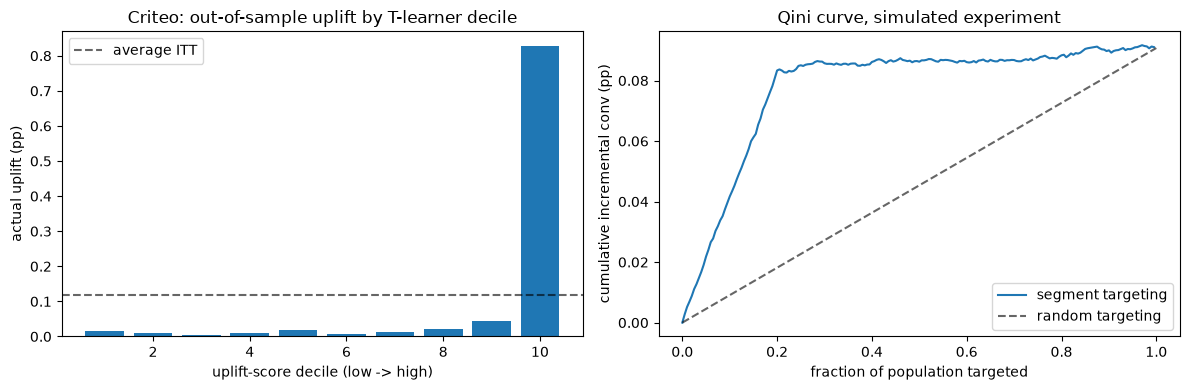

The Qini curve bows modestly above the random-targeting diagonal — realistic heterogeneity, not a toy staircase (spec Section 3 realism check).


In [6]:
# Exhibits: actual uplift by score decile (source) and the Qini curve on simulated data.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 11), dec_uplift.to_numpy() * 100)
axes[0].axhline(ate_ev * 100, ls="--", c="k", alpha=0.6, label="average ITT")
axes[0].set(xlabel="uplift-score decile (low -> high)", ylabel="actual uplift (pp)",
            title="Criteo: out-of-sample uplift by T-learner decile")
axes[0].legend()

# Qini on the simulated experiment, using the injected segment as the targeting score.
s = sim.sort_values("seg", ascending=False).reset_index(drop=True)
frac = np.arange(1, len(s) + 1) / len(s)
cum_t = s.treated.cumsum(); cum_c = (~s.treated).cumsum().clip(lower=1)
qini = (s.conv * s.treated).cumsum() - (s.conv * ~s.treated).cumsum() * (cum_t / cum_c)
step = len(s) // 200
axes[1].plot(frac[::step], qini.to_numpy()[::step] / len(s) * 100, label="segment targeting")
axes[1].plot([0, 1], [0, qini.iloc[-1] / len(s) * 100], ls="--", c="k", alpha=0.6,
             label="random targeting")
axes[1].set(xlabel="fraction of population targeted", ylabel="cumulative incremental conv (pp)",
            title="Qini curve, simulated experiment")
axes[1].legend()
fig.tight_layout()
plt.show()
print("The Qini curve bows modestly above the random-targeting diagonal — realistic "
      "heterogeneity, not a toy staircase (spec Section 3 realism check).")


## 5. Result

`simulation/params/uplift_params.json` is written: fitted ratio/baseline/ATE, measured
heterogeneity spread as segment multipliers, and the declared C5 funnel. All QA gates pass.
With this, all three source datasets are fitted — the Section 5 checklist's fitting row for
Criteo closes, and Phase 1 moves to the simulator stages (`simulation/stages.py`), which must
reproduce these gates from the artifacts alone.
